In [1]:
!pip install torch transformers accelerate datasets -q

In [6]:

"""
SCoRe: Self-Correction via Reinforcement Learning
Model   : distilgpt2
Dataset : GSM8K

COLAB SETUP
───────────
Cell 1:
    !pip install torch transformers accelerate datasets matplotlib -q

Cell 2:
    # paste this entire file

Cell 3:
    trainer, s1_logs, s2_logs = main()

Cell 4 (plots):
    plot_all(s1_logs, s2_logs)

Cell 5 (inference):
    r = infer(trainer, "Janet has 3 apples. She buys 5 more. How many?", gold="8")
    print("Turn 1:", r["turn1"])
    print("Turn 2:", r["turn2"])
    print("Rewards:", r.get("reward1"), r.get("reward2"))

NOTE on accuracy
────────────────
distilgpt2 is an 82M-param base LM with no instruction tuning.
It cannot reliably solve arithmetic, so acc@t1 / acc@t2 will be
very low (0–5%). This is expected. The meaningful signal to watch
is whether Δ(t2−t1) trends positive over Stage II — that shows
the self-correction mechanism is learning even if raw accuracy
stays low. For higher accuracy use Qwen2.5-0.5B-Instruct instead.
"""

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1" 
import copy
import random
import re
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


# ═══════════════════════════════════════════════════════════════════
# 0.  Constants
# ═══════════════════════════════════════════════════════════════════

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float32   # float16 overflows on small GPT-2 → CUDA assert

CORRECTION_PROMPT = (
    "\n\nThere might be an error above. "
    "Please correct any mistake and rewrite the answer.\n\n"
)

# ── canonical log keys (used everywhere) ─────────────────────────
K_ACC1  = "acc_t1"
K_ACC2  = "acc_t2"
K_DELTA = "delta"
K_I2C   = "i_to_c"
K_C2I   = "c_to_i"


# ═══════════════════════════════════════════════════════════════════
# 1.  Config
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Config:
    model_name:        str   = "distilgpt2"

    # Stage I
    stage1_steps:      int   = 300
    beta2:             float = 0.1

    # Stage II
    stage2_steps:      int   = 300
    beta1:             float = 0.01
    alpha:             float = 10.0

    # Optimiser
    lr:                float = 5e-6

    # Sequence budget: must satisfy max_prompt_length + max_new_tokens <= 1024
    max_prompt_length: int   = 400
    max_new_tokens:    int   = 100

    # Training
    batch_size:        int   = 2
    log_every:         int   = 50
    seed:              int   = 42


# ═══════════════════════════════════════════════════════════════════
# 2.  Model
# ═══════════════════════════════════════════════════════════════════

def load_model(cfg: Config):
    print(f"Loading {cfg.model_name}  →  {DEVICE}  ({DTYPE})")
    tok = AutoTokenizer.from_pretrained(cfg.model_name)
    tok.pad_token    = tok.eos_token
    tok.pad_token_id = tok.eos_token_id

    policy = AutoModelForCausalLM.from_pretrained(
        cfg.model_name, dtype=DTYPE
    ).to(DEVICE)
    policy.train()

    ref = copy.deepcopy(policy)
    ref.eval()
    for p in ref.parameters():
        p.requires_grad_(False)

    n = sum(p.numel() for p in policy.parameters()) / 1e6
    print(f"  {n:.1f}M params  |  {DEVICE}  |  {DTYPE}")
    return tok, policy, ref


# ═══════════════════════════════════════════════════════════════════
# 3.  Dataset
# ═══════════════════════════════════════════════════════════════════

def load_gsm8k(split: str = "train", n: int = 300) -> List[Tuple[str, str]]:
    from datasets import load_dataset
    raw  = load_dataset("openai/gsm8k", "main", split=split)
    data = []
    for item in raw.select(range(min(n, len(raw)))):
        m = re.search(r"####\s*(.+)", item["answer"])
        if m:
            gold = m.group(1).strip().replace(",", "")
            data.append((item["question"], gold))
    print(f"Loaded {len(data)} GSM8K [{split}] problems.")
    return data


# ═══════════════════════════════════════════════════════════════════
# 4.  Reward
# ═══════════════════════════════════════════════════════════════════

def gsm8k_reward(prediction: str, gold: str) -> float:
    nums = re.findall(r"-?\d+(?:,\d{3})*(?:\.\d+)?", prediction)
    if not nums:
        return 0.0
    return 1.0 if nums[-1].replace(",", "") == gold.replace(",", "").strip() else 0.0


# ═══════════════════════════════════════════════════════════════════
# 5.  Rollout + metrics
# ═══════════════════════════════════════════════════════════════════

@dataclass
class Rollout:
    problem:   str
    gold:      str
    response1: str
    response2: str
    reward1:   float
    reward2:   float

    @property
    def delta(self) -> float: return self.reward2 - self.reward1
    @property
    def i_to_c(self) -> bool: return self.reward1 == 0.0 and self.reward2 == 1.0
    @property
    def c_to_i(self) -> bool: return self.reward1 == 1.0 and self.reward2 == 0.0


def batch_metrics(rollouts: List[Rollout]) -> Dict[str, float]:
    n = len(rollouts)
    if n == 0:
        return {}
    return {
        K_ACC1:  sum(r.reward1  for r in rollouts) / n,
        K_ACC2:  sum(r.reward2  for r in rollouts) / n,
        K_DELTA: sum(r.delta    for r in rollouts) / n,
        K_I2C:   sum(r.i_to_c  for r in rollouts) / n,
        K_C2I:   sum(r.c_to_i  for r in rollouts) / n,
    }


# ═══════════════════════════════════════════════════════════════════
# 6.  Low-level helpers
# ═══════════════════════════════════════════════════════════════════

def tokenize(tok, text: str, max_len: int) -> Tuple[torch.Tensor, torch.Tensor]:
    enc  = tok(text, return_tensors="pt", truncation=True,
                max_length=max_len, padding=False)
    ids  = enc["input_ids"].to(DEVICE)
    mask = torch.ones_like(ids)
    return ids, mask


@torch.no_grad()
def greedy_generate(model, tok, prompt_ids, prompt_mask, max_new) -> Tuple[torch.Tensor, str]:
    """
    Always greedy (do_sample=False).
    Greedy = argmax at every step — no multinomial sampling,
    """
    out = model.generate(
        input_ids      = prompt_ids,
        attention_mask = prompt_mask,
        max_new_tokens = max_new,
        do_sample      = False,          # ← greedy, never sampling
        pad_token_id   = tok.eos_token_id,
        eos_token_id   = tok.eos_token_id,
    )
    gen = out[:, prompt_ids.shape[1]:]
    if gen.shape[1] == 0:
        gen = torch.full((1, 1), tok.eos_token_id, dtype=torch.long, device=DEVICE)
    return gen, tok.decode(gen[0], skip_special_tokens=True)


def log_prob_and_logits(policy, ref, prompt_ids, gen_ids):
    full = torch.cat([prompt_ids, gen_ids], dim=1)
    T, G = prompt_ids.shape[1], gen_ids.shape[1]

    p_all  = policy(full).logits[0]
    p_gen  = p_all[T - 1 : T + G - 1]
    lp     = F.log_softmax(p_gen, dim=-1)
    lp_sum = lp[torch.arange(G, device=DEVICE), gen_ids[0]].sum()

    with torch.no_grad():
        r_all  = ref(full).logits[0]
        r_gen  = r_all[T - 1 : T + G - 1]

    return lp_sum, p_gen, r_gen


def kl_div(p_logits, r_logits):
    lp = F.log_softmax(p_logits, dim=-1)
    lr = F.log_softmax(r_logits, dim=-1)
    return (lp.exp() * (lp - lr)).sum()


def pg_loss(lp, r, baseline):
    return -((r - baseline) * lp)


# ═══════════════════════════════════════════════════════════════════
# 7.  Trainer
# ═══════════════════════════════════════════════════════════════════

class SCoReTrainer:

    def __init__(self, cfg, tok, policy, ref, dataset):
        self.cfg     = cfg
        self.tok     = tok
        self.policy  = policy
        self.ref     = ref
        self.dataset = dataset
        self.opt     = torch.optim.AdamW(policy.parameters(), lr=cfg.lr)

    def _tok(self, text):
        return tokenize(self.tok, text, self.cfg.max_prompt_length)

    def _gen(self, ids, mask):
        return greedy_generate(self.policy, self.tok, ids, mask, self.cfg.max_new_tokens)

    def _lp(self, p_ids, g_ids):
        return log_prob_and_logits(self.policy, self.ref, p_ids, g_ids)

    def _rollout(self, problem: str, gold: str) -> Rollout:
        p1, m1    = self._tok(problem)
        g1, resp1 = self._gen(p1, m1)
        r1        = gsm8k_reward(resp1, gold)

        ctx2      = problem + resp1 + CORRECTION_PROMPT
        p2, m2    = self._tok(ctx2)
        g2, resp2 = self._gen(p2, m2)
        r2        = gsm8k_reward(resp2, gold)

        return Rollout(problem, gold, resp1, resp2, r1, r2)

    def _batch(self):
        return random.choices(self.dataset, k=self.cfg.batch_size)

    # ── Stage I ──────────────────────────────────────────────────

    def stage1(self) -> List[Dict]:
        print("=" * 56)
        print("STAGE I — decouple turns via turn-1 KL constraint")
        print("=" * 56)
        cfg, logs, buf = self.cfg, [], []

        for step in range(cfg.stage1_steps):
            batch    = self._batch()
            rollouts = [self._rollout(p, g) for p, g in batch]
            buf.extend(rollouts)

            b2 = sum(x.reward2 for x in rollouts) / len(rollouts)
            self.opt.zero_grad()
            loss = torch.tensor(0.0, device=DEVICE)

            for ro, (prob, _) in zip(rollouts, batch):
                p1, _ = self._tok(prob)
                g1, _ = self._tok(ro.response1)
                ctx2  = prob + ro.response1 + CORRECTION_PROMPT
                p2, _ = self._tok(ctx2)
                g2, _ = self._tok(ro.response2)

                lp2, _, _   = self._lp(p2, g2)
                _, pl1, rl1 = self._lp(p1, g1)
                loss = loss + pg_loss(lp2, ro.reward2, b2) + cfg.beta2 * kl_div(pl1, rl1)

            (loss / len(rollouts)).backward()
            torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
            self.opt.step()

            if step % cfg.log_every == 0:
                m = batch_metrics(buf)
                m.update(step=step, stage=1, loss=loss.item() / len(rollouts))
                logs.append(m)
                buf = []
                print(f"  step {step:4d} | loss={m['loss']:8.3f} | "
                      f"acc@t1={m[K_ACC1]:.3f}  acc@t2={m[K_ACC2]:.3f}  "
                      f"Δ={m[K_DELTA]:+.3f}  i→c={m[K_I2C]:.3f}  c→i={m[K_C2I]:.3f}")

        print("Stage I done.\n")
        return logs

    # ── Stage II ─────────────────────────────────────────────────

    def stage2(self) -> List[Dict]:
        print("=" * 56)
        print("STAGE II — joint optimisation with reward shaping")
        print("=" * 56)
        cfg, logs, buf = self.cfg, [], []

        for step in range(cfg.stage2_steps):
            batch    = self._batch()
            rollouts = [self._rollout(p, g) for p, g in batch]
            buf.extend(rollouts)

            b1 = sum(x.reward1 for x in rollouts) / len(rollouts)
            b2 = sum(x.reward2 + cfg.alpha * x.delta for x in rollouts) / len(rollouts)
            self.opt.zero_grad()
            loss = torch.tensor(0.0, device=DEVICE)

            for ro, (prob, _) in zip(rollouts, batch):
                p1, _ = self._tok(prob)
                g1, _ = self._tok(ro.response1)
                ctx2  = prob + ro.response1 + CORRECTION_PROMPT
                p2, _ = self._tok(ctx2)
                g2, _ = self._tok(ro.response2)

                lp1, pl1, rl1 = self._lp(p1, g1)
                lp2, pl2, rl2 = self._lp(p2, g2)
                r2s = ro.reward2 + cfg.alpha * ro.delta

                loss = (loss
                        + pg_loss(lp1, ro.reward1, b1) + cfg.beta1 * kl_div(pl1, rl1)
                        + pg_loss(lp2, r2s, b2)         + cfg.beta1 * kl_div(pl2, rl2))

            (loss / len(rollouts)).backward()
            torch.nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
            self.opt.step()

            if step % cfg.log_every == 0:
                m = batch_metrics(buf)
                m.update(step=step, stage=2, loss=loss.item() / len(rollouts))
                logs.append(m)
                buf = []
                print(f"  step {step:4d} | loss={m['loss']:8.3f} | "
                      f"acc@t1={m[K_ACC1]:.3f}  acc@t2={m[K_ACC2]:.3f}  "
                      f"Δ={m[K_DELTA]:+.3f}  i→c={m[K_I2C]:.3f}  c→i={m[K_C2I]:.3f}")

        print("Stage II done.")
        return logs


# ═══════════════════════════════════════════════════════════════════
# 8.  Inference  (always greedy)
# ═══════════════════════════════════════════════════════════════════

@torch.no_grad()
def infer(trainer: SCoReTrainer, problem: str, gold: str = None) -> Dict:
    cfg, tok, model = trainer.cfg, trainer.tok, trainer.policy
    out = {}
    context = problem

    for turn in range(2):          # turn 0 = initial, turn 1 = correction
        ids, mask = tokenize(tok, context, cfg.max_prompt_length)
        gen, text = greedy_generate(model, tok, ids, mask, cfg.max_new_tokens)
        key = f"turn{turn + 1}"
        out[key] = text if text.strip() else "(empty — model produced no text)"
        if gold is not None:
            out[f"reward{turn + 1}"] = gsm8k_reward(text, gold)
        context = context + text + CORRECTION_PROMPT

    return out


# ═══════════════════════════════════════════════════════════════════
# 9.  Evaluation
# ═══════════════════════════════════════════════════════════════════

def evaluate(trainer: SCoReTrainer, data: List[Tuple[str, str]], n: int = 50) -> Dict:
    sample   = random.sample(data, min(n, len(data)))
    rollouts = [trainer._rollout(p, g) for p, g in sample]
    m        = batch_metrics(rollouts)
    print(f"\n── Eval ({len(sample)} problems) ──────────────────────")
    print(f"  acc@t1  = {m[K_ACC1]:.3f}")
    print(f"  acc@t2  = {m[K_ACC2]:.3f}")
    print(f"  Δ       = {m[K_DELTA]:+.3f}")
    print(f"  i→c     = {m[K_I2C]:.3f}")
    print(f"  c→i     = {m[K_C2I]:.3f}")
    return m


# ═══════════════════════════════════════════════════════════════════
# 10.  Main
# ═══════════════════════════════════════════════════════════════════

def main(n_train: int = 300, cfg: Config = None):
    if cfg is None:
        cfg = Config()

    random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    tok, policy, ref = load_model(cfg)
    dataset          = load_gsm8k("train", n=n_train)

    print(f"\nModel   : {cfg.model_name}")
    print(f"Dataset : GSM8K ({len(dataset)} problems)")
    print(f"Device  : {DEVICE}  |  dtype: {DTYPE}")
    print(f"Stage I : {cfg.stage1_steps} steps | Stage II : {cfg.stage2_steps} steps")
    print(f"Batch   : {cfg.batch_size} | α={cfg.alpha}  β1={cfg.beta1}  β2={cfg.beta2}\n")

    trainer = SCoReTrainer(cfg, tok, policy, ref, dataset)
    s1      = trainer.stage1()
    s2      = trainer.stage2()
    return trainer, s1, s2


# ═══════════════════════════════════════════════════════════════════
# 11.  Plots  — all keys aligned with batch_metrics output
# ═══════════════════════════════════════════════════════════════════

def _get(logs, key):
    return [m[key] for m in logs if key in m]

def _steps(logs):
    return [m["step"] for m in logs]

def _final(logs, key, default=0.0):
    vals = _get(logs, key)
    return vals[-1] if vals else default

def _offset_steps(s2_logs, s1_logs):
    """Shift stage-2 steps so they continue after stage-1 on the x-axis."""
    if not s1_logs:
        return _steps(s2_logs)
    last = _steps(s1_logs)[-1] if _steps(s1_logs) else 0
    gap  = s1_logs[0]["step"] if s1_logs else 50
    return [m["step"] + last + gap for m in s2_logs if "step" in m]

def _divider(ax, s1_logs, s2_steps):
    s1s = _steps(s1_logs)
    if s1s and s2_steps:
        div = (s1s[-1] + s2_steps[0]) / 2
        ax.axvline(div, color="grey", ls="--", lw=1, alpha=0.6)
        ylim = ax.get_ylim()
        ax.text(div + 2, ylim[1] * 0.97, "I→II", fontsize=7,
                color="grey", va="top")


def plot_accuracy_curves(s1, s2, ax):
    s1s = _steps(s1);          s2s = _offset_steps(s2, s1)
    ax.plot(s1s + s2s, _get(s1, K_ACC1) + _get(s2, K_ACC1),
            color="#4C72B0", lw=2, label="acc@t1")
    ax.plot(s1s + s2s, _get(s1, K_ACC2) + _get(s2, K_ACC2),
            color="#DD8452", lw=2, label="acc@t2")
    _divider(ax, s1, s2s)
    ax.set_title("Accuracy over Training", fontweight="bold")
    ax.set_xlabel("Step"); ax.set_ylabel("Accuracy")
    ax.set_ylim(0, max(0.15, max(_get(s1, K_ACC2) + _get(s2, K_ACC2) + [0.01]) * 1.3))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)


def plot_delta_curve(s1, s2, ax):
    s1s  = _steps(s1);  s2s = _offset_steps(s2, s1)
    allx = s1s + s2s
    ally = _get(s1, K_DELTA) + _get(s2, K_DELTA)
    colors = ["#2ca02c" if d >= 0 else "#d62728" for d in ally]
    ax.bar(allx, ally, width=18, color=colors, alpha=0.8)
    ax.axhline(0, color="black", lw=0.8)
    _divider(ax, s1, s2s)

    # annotate final delta
    if ally:
        fd = ally[-1]
        ax.annotate(f"Final Δ = {fd:+.3f}",
                    xy=(allx[-1], fd),
                    xytext=(-55, 22 if fd >= 0 else -28),
                    textcoords="offset points", fontsize=9, fontweight="bold",
                    color="#2d6a2d" if fd >= 0 else "#8b0000",
                    arrowprops=dict(arrowstyle="->", color="grey", lw=1))

    ax.set_title("Δ(acc@t2 − acc@t1) over Training", fontweight="bold")
    ax.set_xlabel("Step"); ax.set_ylabel("Δ")
    ax.grid(True, alpha=0.3, axis="y")


def plot_correction_rates(s1, s2, ax):
    s1s = _steps(s1);  s2s = _offset_steps(s2, s1)
    allx = s1s + s2s
    ax.plot(allx, _get(s1, K_I2C) + _get(s2, K_I2C),
            color="#2ca02c", lw=2, marker="o", ms=4, label="i→c (fixed)")
    ax.plot(allx, _get(s1, K_C2I) + _get(s2, K_C2I),
            color="#d62728", lw=2, marker="s", ms=4, label="c→i (broken)")
    _divider(ax, s1, s2s)
    ax.set_title("Correction Rates over Training", fontweight="bold")
    ax.set_xlabel("Step"); ax.set_ylabel("Rate")
    ax.set_ylim(0, max(0.15,
        max(_get(s1, K_I2C) + _get(s2, K_I2C) + _get(s1, K_C2I) + _get(s2, K_C2I) + [0.01]) * 1.3))
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)


def plot_loss(s1, s2, ax):
    ax.plot(_steps(s1), _get(s1, "loss"), color="#9467bd", lw=2, label="Stage I")
    ax.plot(_offset_steps(s2, s1), _get(s2, "loss"), color="#8c564b", lw=2, label="Stage II")
    ax.set_title("Training Loss", fontweight="bold")
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)


def plot_stage_bar(s1, s2, ax):
    keys   = [K_ACC1, K_ACC2, K_DELTA, K_I2C, K_C2I]
    labels = ["acc@t1", "acc@t2", "Δ(t2−t1)", "i→c", "c→i"]
    s1v    = [_final(s1, k) for k in keys]
    s2v    = [_final(s2, k) for k in keys]
    x      = np.arange(len(labels)); w = 0.35

    b1 = ax.bar(x - w/2, s1v, w, label="Stage I",  color="#4C72B0", alpha=0.85)
    b2 = ax.bar(x + w/2, s2v, w, label="Stage II", color="#DD8452", alpha=0.85)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + w/2, h + 0.003,
                f"{h:+.3f}" if abs(h) < 1 else f"{h:.3f}",
                ha="center", va="bottom", fontsize=7)

    # bold border on Δ bars
    for bar in [b1[2], b2[2]]:
        bar.set_edgecolor("#222"); bar.set_linewidth(2)

    # annotate final stage-2 delta
    fd = s2v[2]
    ax.annotate(f"Final Δ = {fd:+.3f}",
                xy=(x[2] + w/2, fd),
                xytext=(0, 30), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold",
                color="#2d6a2d" if fd >= 0 else "#8b0000",
                arrowprops=dict(arrowstyle="->", color="grey", lw=1.2))

    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
    ax.set_title("Stage I vs Stage II — Final Metrics", fontweight="bold")
    ax.set_ylabel("Value"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")


def plot_acc_bar_per_stage(s1, s2, ax):
    cats = ["Stage I", "Stage II"]
    t1v  = [_final(s1, K_ACC1), _final(s2, K_ACC1)]
    t2v  = [_final(s1, K_ACC2), _final(s2, K_ACC2)]
    x    = np.arange(2); w = 0.3

    b1 = ax.bar(x - w/2, t1v, w, label="acc@t1", color="#4C72B0", alpha=0.85)
    b2 = ax.bar(x + w/2, t2v, w, label="acc@t2", color="#DD8452", alpha=0.85)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + w/2, h + 0.002, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9)

    # delta arrow per stage
    top = max(max(t1v + t2v) * 1.4, 0.05)
    for i in range(2):
        d    = t2v[i] - t1v[i]
        ypos = max(t1v[i], t2v[i]) + top * 0.12
        ax.annotate("", xy=(x[i]+w/2, ypos), xytext=(x[i]-w/2, ypos),
                    arrowprops=dict(arrowstyle="->",
                                    color="#2d6a2d" if d >= 0 else "#d62728", lw=2))
        ax.text(x[i], ypos + top * 0.04, f"Δ={d:+.3f}",
                ha="center", fontsize=9, fontweight="bold",
                color="#2d6a2d" if d >= 0 else "#d62728")

    ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=11)
    ax.set_title("acc@t1 vs acc@t2 per Stage", fontweight="bold")
    ax.set_ylabel("Accuracy"); ax.set_ylim(0, top)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")


def plot_all(s1_logs, s2_logs, save_path=None):
    """
    Draw all 6 panels.

    Usage:
        plot_all(s1_logs, s2_logs)
        plot_all(s1_logs, s2_logs, save_path="score_results.png")
    """
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("SCoRe Training — distilgpt2 on GSM8K",
                 fontsize=14, fontweight="bold", y=1.01)
    gs = gridspec.GridSpec(3, 2, hspace=0.48, wspace=0.35)

    plot_accuracy_curves    (s1_logs, s2_logs, fig.add_subplot(gs[0, 0]))
    plot_delta_curve        (s1_logs, s2_logs, fig.add_subplot(gs[0, 1]))
    plot_correction_rates   (s1_logs, s2_logs, fig.add_subplot(gs[1, 0]))
    plot_loss               (s1_logs, s2_logs, fig.add_subplot(gs[1, 1]))
    plot_stage_bar          (s1_logs, s2_logs, fig.add_subplot(gs[2, 0]))
    plot_acc_bar_per_stage  (s1_logs, s2_logs, fig.add_subplot(gs[2, 1]))

    # summary strip at bottom
    s1d = _final(s1_logs, K_DELTA); s2d = _final(s2_logs, K_DELTA)
    summary = (
        f"Stage I  final:  acc@t1={_final(s1_logs,K_ACC1):.3f}  acc@t2={_final(s1_logs,K_ACC2):.3f}"
        f"  Δ={s1d:+.3f}  i→c={_final(s1_logs,K_I2C):.3f}  c→i={_final(s1_logs,K_C2I):.3f}\n"
        f"Stage II final:  acc@t1={_final(s2_logs,K_ACC1):.3f}  acc@t2={_final(s2_logs,K_ACC2):.3f}"
        f"  Δ={s2d:+.3f}  i→c={_final(s2_logs,K_I2C):.3f}  c→i={_final(s2_logs,K_C2I):.3f}\n"
        f"Self-correction {'IMPROVED ✓' if s2d > s1d else 'did not improve ✗'}  "
        f"(Δ: {s1d:+.3f} → {s2d:+.3f})"
    )
    fig.text(0.5, -0.015, summary, ha="center", va="top", fontsize=9,
             family="monospace",
             bbox=dict(boxstyle="round,pad=0.5", facecolor="#f5f5f5",
                       edgecolor="#cccccc", alpha=0.95))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()

    print(f"\nFinal Δ(t1,t2):")
    print(f"  Stage I  : {s1d:+.3f}")
    print(f"  Stage II : {s2d:+.3f}")

In [7]:
trainer, s1_logs, s2_logs = main()

Loading distilgpt2  →  cuda  (torch.float32)


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Loaded 300 GSM8K [train] problems.

Model   : distilgpt2
Dataset : GSM8K (300 problems)
Device  : cuda  |  dtype: torch.float32
Stage I : 300 steps | Stage II : 300 steps
Batch   : 2 | α=10.0  β1=0.01  β2=0.1

STAGE I — decouple turns via turn-1 KL constraint
  step    0 | loss=   0.389 | acc@t1=0.000  acc@t2=0.000  Δ=+0.000  i→c=0.000  c→i=0.000
  step   50 | loss=   0.501 | acc@t1=0.000  acc@t2=0.010  Δ=+0.010  i→c=0.010  c→i=0.000
  step  100 | loss=   0.238 | acc@t1=0.010  acc@t2=0.010  Δ=+0.000  i→c=0.000  c→i=0.000
  step  150 | loss=   0.195 | acc@t1=0.000  acc@t2=0.000  Δ=+0.000  i→c=0.000  c→i=0.000
  step  200 | loss=   0.323 | acc@t1=0.010  acc@t2=0.000  Δ=-0.010  i→c=0.000  c→i=0.010
  step  250 | loss=   0.225 | acc@t1=0.010  acc@t2=0.000  Δ=-0.010  i→c=0.000  c→i=0.010
Stage I done.

STAGE II — joint optimisation with reward shaping
  step    0 | loss=   0.050 | acc@t1=0.000  acc@t2=0.000  Δ=+0.000  i→c=0.000  c→i=0.000
  step   50 | loss=   0.073 | acc@t1=0.020  acc@t2=0

/tmp/ipykernel_57/2670692335.py:643: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


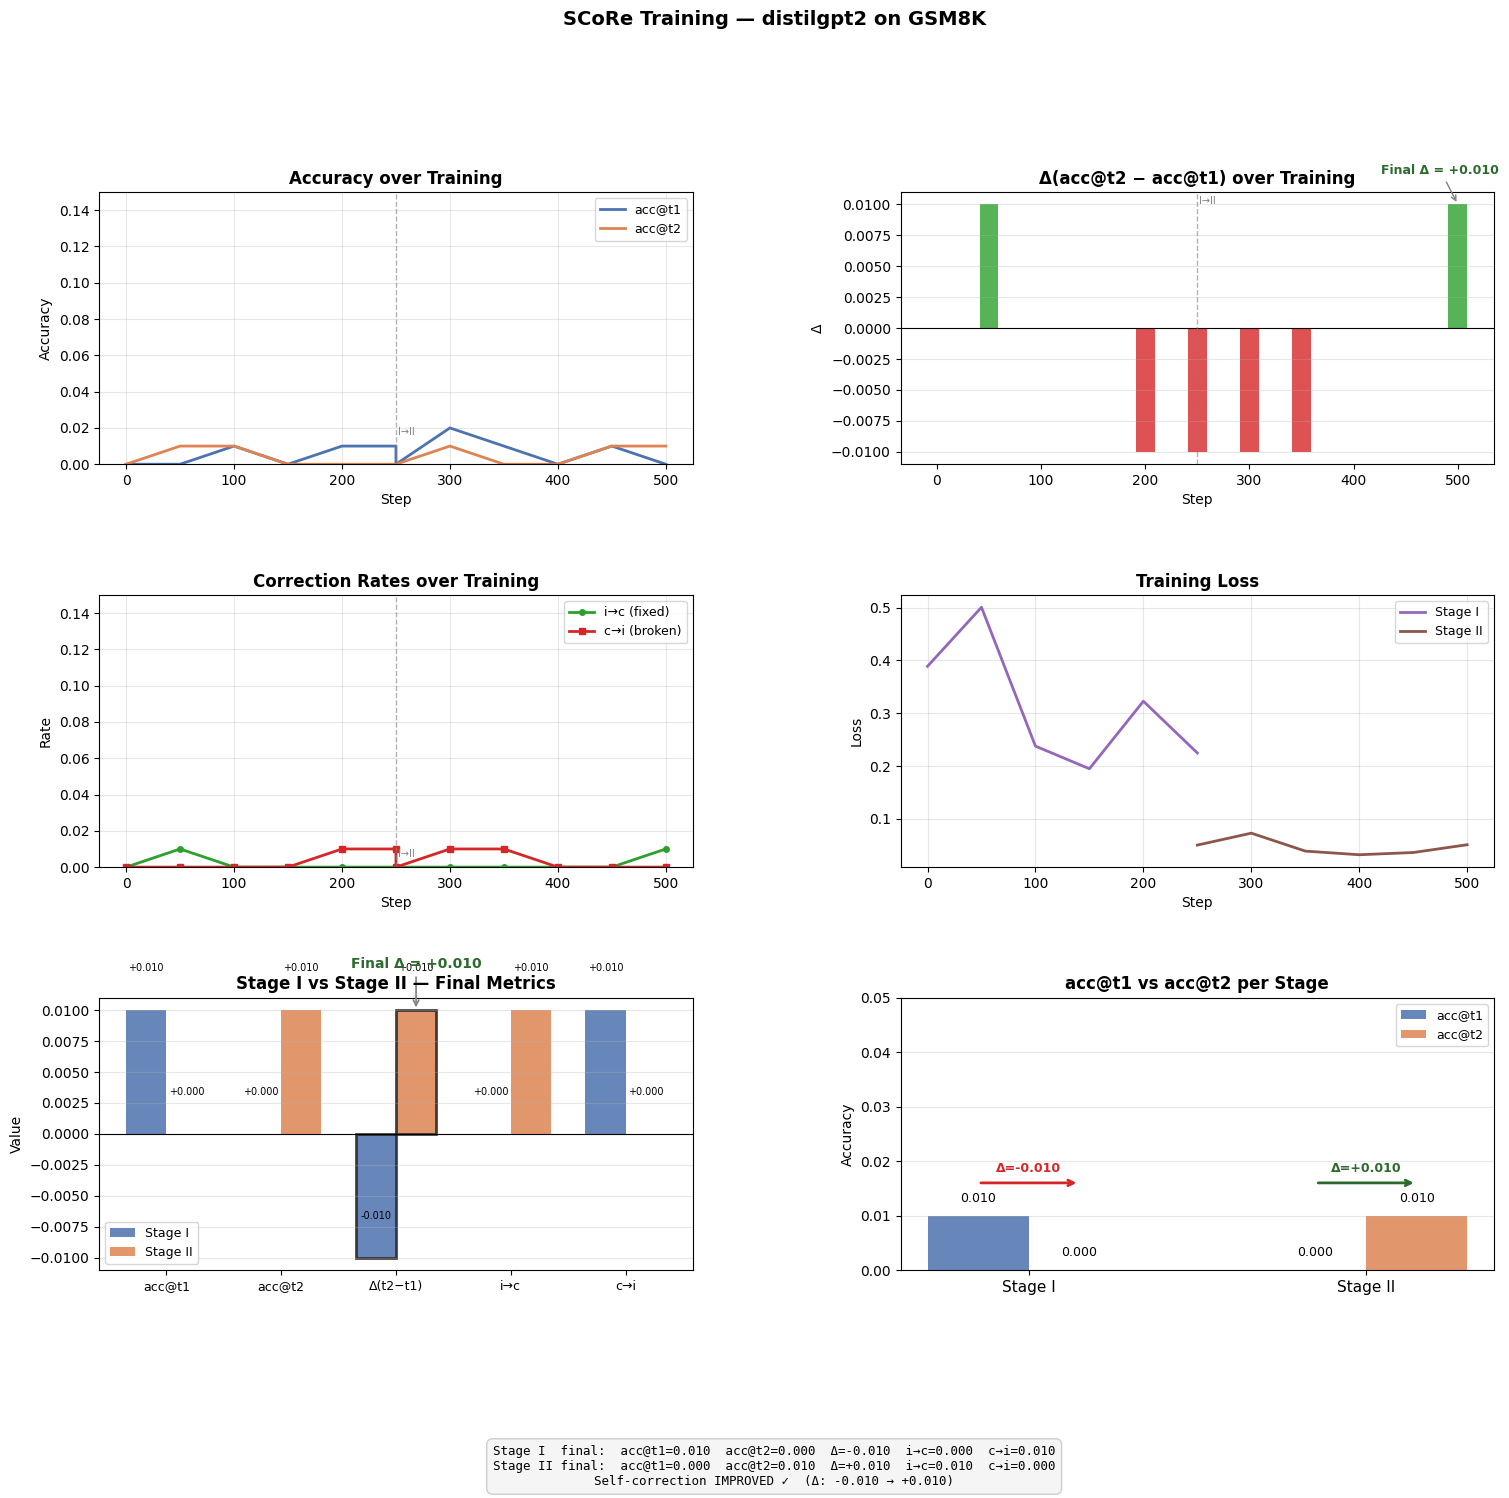


Final Δ(t1,t2):
  Stage I  : -0.010
  Stage II : +0.010


In [8]:
plot_all(s1_logs, s2_logs)

## **Installing dependencies**

In [2]:
!pip install -q transformers accelerate bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.1 MB/s eta 0:00:00:00:0100:01


## **Imports**

In [3]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"

## **Models Used**

In [8]:
GEN_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

CRITIC_MODEL_NAME = "microsoft/Phi-3.5-mini-instruct" # 3.8B

## **Loading Generator model for generating and self reflecting**

In [6]:
gen_tokenizer = AutoTokenizer.from_pretrained(
    GEN_MODEL_NAME
)

gen_model = AutoModelForCausalLM.from_pretrained(
    GEN_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

## **Loading Critic Model for Critisizing generator's response**

In [9]:
critic_tokenizer = AutoTokenizer.from_pretrained(
    CRITIC_MODEL_NAME
)

critic_model = AutoModelForCausalLM.from_pretrained(
    CRITIC_MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Models Loaded")

config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

Models Loaded


## **Shared function for generating response**

In [45]:
import torch

def generate(model, tokenizer, messages, max_new_tokens=400):
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    input_length = inputs["input_ids"].shape[1]          # <-- token count of prompt

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True
        )

    new_tokens = outputs[0][input_length:]               # <-- slice off prompt tokens
    decoded = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return decoded.strip()

## **Step1: Generation using the generator model and self reflection**

In [46]:
def generate_answer(question):

    messages = [
        {
            "role": "user",
            "content": f"""
You are an expert AI assistant.

Solve the question step by step and provide a clear final answer.

Question:
{question}
"""
        }
    ]

    return generate(gen_model, gen_tokenizer, messages, max_new_tokens=600)

def self_correct(question, answer):

    messages = [
        {
            "role": "user",
            "content": f"""
You are a strict self-correcting AI.

You previously answered a question. Now improve it.

Question:
{question}

Your Previous Answer:
{answer}

Task:
- Find mistakes
- Fix reasoning
- Improve clarity and correctness
- Produce FINAL improved answer only
"""
        }
    ]

    return generate(gen_model, gen_tokenizer, messages,max_new_tokens=600)

## **STEP2: Critic + Stronger answer**

In [47]:
def critic_and_answer(question, generator_final):

    messages = [
        {
            "role": "user",
            "content": f"""
You are an expert critic and solver.

You will:
1. Critically evaluate the generator's final answer
2. Identify errors
3. Then produce your own improved best answer

Question:
{question}

Generator Final Answer:
{generator_final}

Output:
A) Critique
B) Your Improved Final Answer
"""
        }
    ]

    return generate(critic_model, critic_tokenizer, messages, max_new_tokens=800)

## **Step 3: Comparision**

In [48]:
def compare(question, gen_final, critic_output):

    messages = [
        {
            "role": "user",
            "content": f"""
You are an impartial evaluator.

Compare two answers and decide which is better.

Question:
{question}

Answer A (Generator Self-Corrected):
{gen_final}

Answer B (Critic Model Answer):
{critic_output}

Task:
1. Choose best answer (A or B) 
2. Explain why


Output Format:
Better: [Better answer here(A or B)]
Explanation: [explanation here]
"""
        }
    ]

    return generate(gen_model, gen_tokenizer, messages,max_new_tokens=200)

## **Step4: Run**

In [49]:
def pipeline(question):

    print("\n=== STEP 1: GENERATOR ===\n")
    gen1 = generate_answer(question)
    print(gen1)

    print("\n=== STEP 2: SELF CORRECTION (MODEL 1 AGAIN) ===\n")
    gen_final = self_correct(question, gen1)
    print(gen_final)

    print("\n=== STEP 3: CRITIC (MODEL 2) ===\n")
    critic_out = critic_and_answer(question, gen_final)
    print(critic_out)

    print("\n=== STEP 4: COMPARISON ===\n")
    final = compare(question, gen_final, critic_out)
    print(final)

    return final

In [50]:
question="Explain how transformers work in deep learning, including self-attention, and why they perform better than RNNs. Include intuition and key equations."
pipeline(question)


=== STEP 1: GENERATOR ===

Transformers are neural network architectures that have become popular for natural language processing (NLP) due to their superior performance compared to Recurrent Neural Networks (RNNs). The key idea behind Transformers is to leverage self-attention mechanisms to allow each token in the input sequence to be fully aware of every other token without needing to explicitly "look ahead" or "look back," which is computationally expensive for long sequences.

### Self-Attention Mechanism
Self-attention allows a transformer model to weigh the importance of different parts of the input based on their relevance to the current task. This mechanism can be described as follows:

1. **Input Representation**: Each element \( x_i \) in the input sequence has a corresponding embedding vector \( e_i \).
2. **Normalization**: Before applying attention, we normalize the embeddings using Layer Normalization: \( \text{LN}(e_i) = \frac{e_i - \bar{e}_i}{\sqrt{\text{dim}} + 10^{-6

'Better: Answer A (Generator Self-Corrected)\n\nExplanation: Answer A provides a clear and concise introduction to the Transformer architecture, focusing on the self-attention mechanism and explaining why it performs better than RNNs. It also includes the key equations necessary for understanding the self-attention mechanism, such as the dot product attention formula. This approach offers both technical detail and intuitive explanations, making it easier for readers to grasp the fundamental concepts of Transformers. Additionally, Answer A highlights the benefits of self-attention over RNNs, touching on points like avoiding vanishing/exploding gradients and capturing long-range dependencies, which are crucial for a deeper understanding of why Transformers excel in certain contexts.'

## **Now we will compare the self correction and critic models on 50 different questions and plot the results in a bar graph to see which gives better results**

In [51]:
questions = [
    "What is overfitting and how can it be prevented?",
    "What is underfitting in machine learning?",
    "Explain bias-variance tradeoff.",
    "What is regularization? Compare L1 and L2.",
    "Why do we need train-test split?",
    "What is cross-validation?",
    "Explain precision, recall, and F1-score.",
    "What is a confusion matrix?",
    "Why does data normalization help models?",
    "Difference between classification and regression.",
    "What is gradient descent?",
    "Why is learning rate important?",
    "What is stochastic gradient descent?",
    "Explain feature scaling and its importance.",
    "What is a loss function?",

    "What is a neural network?",
    "What is backpropagation?",
    "Explain vanishing gradient problem.",
    "Why ReLU is preferred over sigmoid?",
    "What is dropout in neural networks?",
    "What is batch normalization?",
    "What is CNN and where is it used?",
    "What is pooling in CNN?",
    "Difference between CNN and RNN.",
    "What is an RNN?",
    "What is LSTM and why is it used?",
    "What is GRU?",
    "Why do transformers outperform RNNs?",
    "What is attention mechanism?",
    "What is self-attention?",

    "How do transformers work?",
    "What is positional encoding?",
    "Why is softmax used in attention?",
    "What is multi-head attention?",
    "Difference between encoder and decoder.",
    "What is BERT?",
    "What is GPT architecture?",
    "Why are transformers parallelizable?",

    "Why does O(n^2) complexity occur in self-attention?",
    "How can we reduce attention complexity?",
    "Explain probability vs likelihood.",
    "What is Bayes theorem?",
    "What is expectation in probability?",
    "What is entropy in information theory?",
    "Why does high variance lead to overfitting?",

    "A model has 99% training accuracy but 60% test accuracy. Why?",
    "Why can accuracy be misleading in imbalanced datasets?",
    "What happens if learning rate is too high?",
    "Why might a deeper network perform worse than a shallow one?",
    "If two models have same accuracy, how do you choose between them?"
]

In [52]:
gen_wins = 0
critic_wins = 0
results = []

In [53]:
import re

def parse_decision(decision):
    match = re.search(r'better\s*:\s*\[?\s*(a|b)\s*\]?', decision.lower())
    if match:
        return match.group(1)
    if re.search(r'\b(answer a|option a|choose a|winner.{0,10}a)\b', decision.lower()):
        return 'a'
    if re.search(r'\b(answer b|option b|choose b|winner.{0,10}b)\b', decision.lower()):
        return 'b'
    return None

In [54]:
for q in questions:

    # Model 1
    gen1 = generate_answer(q)
    gen_final = self_correct(q, gen1)

    # Model 2
    critic_out = critic_and_answer(q, gen_final)

    # Compare
    decision = compare(q, gen_final, critic_out)

    decision_lower = decision.lower()

    # --- SAFE PARSING ---
    winner = parse_decision(decision)
    if winner == 'a':
        gen_wins += 1
        results.append(1)
    elif winner == 'b':
        critic_wins += 1
        results.append(0)
    else:
        results.append(-1)  # undecided

    print("Done:", q)

total = len(questions)
undecided = results.count(-1)
print(f"\n=== FINAL RESULTS ===")
print(f"Generator (Qwen):  {gen_wins}/{total}")
print(f"Critic (Phi-3.5):  {critic_wins}/{total}")
print(f"Undecided:         {undecided}/{total}")

Done: What is overfitting and how can it be prevented?
Done: What is underfitting in machine learning?
Done: Explain bias-variance tradeoff.
Done: What is regularization? Compare L1 and L2.
Done: Why do we need train-test split?
Done: What is cross-validation?
Done: Explain precision, recall, and F1-score.
Done: What is a confusion matrix?
Done: Why does data normalization help models?
Done: Difference between classification and regression.
Done: What is gradient descent?
Done: Why is learning rate important?
Done: What is stochastic gradient descent?
Done: Explain feature scaling and its importance.
Done: What is a loss function?
Done: What is a neural network?
Done: What is backpropagation?
Done: Explain vanishing gradient problem.
Done: Why ReLU is preferred over sigmoid?
Done: What is dropout in neural networks?
Done: What is batch normalization?
Done: What is CNN and where is it used?
Done: What is pooling in CNN?
Done: Difference between CNN and RNN.
Done: What is an RNN?
Done: W

## **Charts**

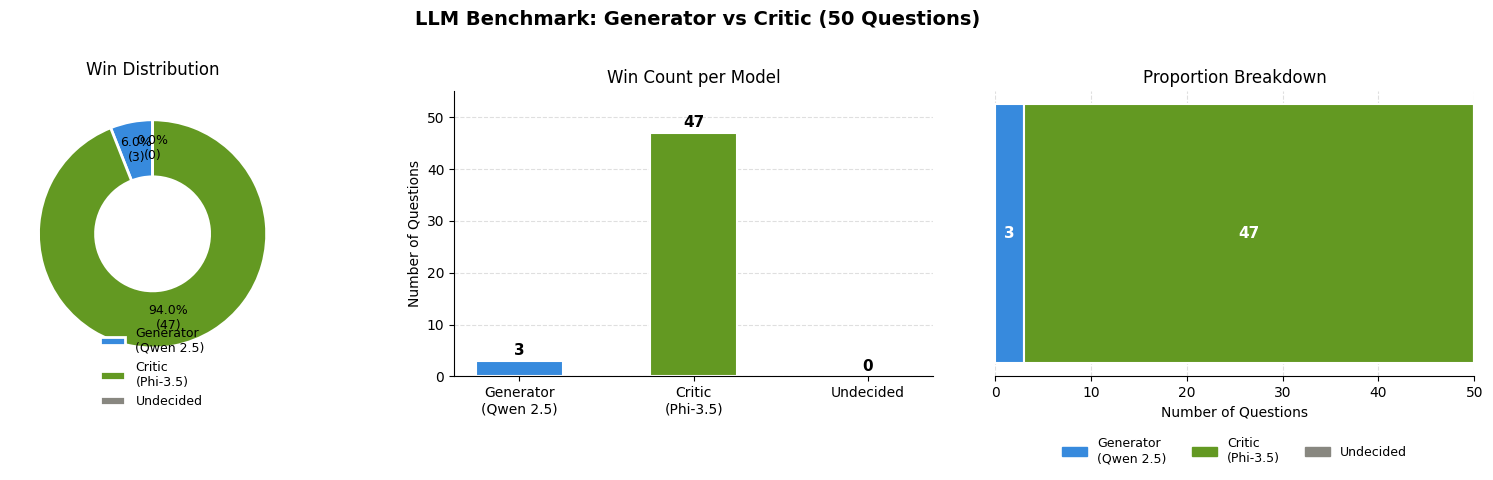

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
total      = len(questions)
undecided  = results.count(-1)
labels     = ['Generator\n(Qwen 2.5)', 'Critic\n(Phi-3.5)', 'Undecided']
values     = [gen_wins, critic_wins, undecided]
colors     = ['#378ADD', '#639922', '#888780']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('LLM Benchmark: Generator vs Critic (50 Questions)', fontsize=14, fontweight='bold', y=1.02)

# ── Chart 1: Donut ────────────────────────────────────────────────────────────
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    values,
    labels=None,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*total/100))})',
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)
ax1.set_title('Win Distribution', fontsize=12, pad=12)
ax1.legend(wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.15), fontsize=9, frameon=False)

# ── Chart 2: Bar ──────────────────────────────────────────────────────────────
ax2 = axes[1]
bars = ax2.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar_obj, val in zip(bars, values):
    ax2.text(
        bar_obj.get_x() + bar_obj.get_width() / 2,
        bar_obj.get_height() + 0.5,
        str(val),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax2.set_ylim(0, total + 5)
ax2.set_ylabel('Number of Questions')
ax2.set_title('Win Count per Model', fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)

# ── Chart 3: Stacked Horizontal Bar ───────────────────────────────────────────
ax3 = axes[2]
starts = [0, gen_wins, gen_wins + critic_wins]
for start, val, color, label in zip(starts, values, colors, labels):
    ax3.barh(['Results'], [val], left=[start], color=color, label=label, height=0.4, edgecolor='white', linewidth=1.5)
    if val > 0:
        ax3.text(
            start + val / 2, 0,
            f'{val}', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white'
        )
ax3.set_xlim(0, total)
ax3.set_xlabel('Number of Questions')
ax3.set_title('Proportion Breakdown', fontsize=12)
ax3.spines[['top', 'right', 'left']].set_visible(False)
ax3.yaxis.set_visible(False)
ax3.xaxis.grid(True, linestyle='--', alpha=0.4)
ax3.set_axisbelow(True)
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
ax3.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.35), ncol=3, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()